# ASNA 2026 GLP-1 Effects Graphs
We receive the GLP-1 dataset. Let's simply get some general information from the dataset first!

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

train.head(n=3)

,ID,Age,Sex,Smoker Status,BMI,Health Status,GLP-1,GLP-1 Duration in Years,Province,Face Amount,Death Flag
0,1,56,F,No,28.5,Good,0,NaN,Quebec,"$750,000",0
1,2,50,F,No,26.7,Good,1,3.2,Manitoba,"$250,000",0
2,3,27,F,Yes,33.1,Good,1,0.0,Ontario,"$250,000",0


In [2]:
test.head(n=3)

,ID,Age,Sex,Smoker Status,BMI,Health Status,GLP-1,GLP-1 Duration in Years,Province,Face Amount,Usage
0,10001,54,F,No,31.9,Good,0,NaN,British Columbia,"$5,000,000",Public
1,10002,67,F,No,32.2,Fair,0,NaN,Quebec,"$500,000",Public
2,10003,56,M,No,28.5,Good,0,NaN,Alberta,"$2,000,000",Public


In [3]:
train['Death Flag'].value_counts(normalize = True)

Death Flag
0    0.9838
1    0.0162
Name: proportion, dtype: float64

We only have around 1.6% of death flags in the data set, we can use a light model in this case! Now let's check all the empty data in the set.

In [4]:
train.isnull().sum()

ID                            0
Age                           0
Sex                           0
Smoker Status                 0
BMI                           0
Health Status                 0
GLP-1                         0
GLP-1 Duration in Years    7688
Province                      0
Face Amount                   0
Death Flag                    0
dtype: int64

Yup, we can do some data cleaning with the GLP-1 Duration in Years Section. 

With that in mind, Data Clean Time!
 

In [5]:
city_codes = {'Quebec': 0, 'Manitoba': 1, 'Ontario': 2, 
              'British Columbia' : 3, 'Alberta' : 4, 'Newfoundland & Labrador' : 5, 
              'Saskatchewan' : 6, 'Nova Scotia' : 7, 'New Brunswick' : 8,
              'Nunavut' : 9, 'Prince Edward Island' : 10, 'Yukon' : 11,
              'Northwest Territories' : 12}

def clean(df):
    df = df.copy()
    df.columns = df.columns.str.strip()

    if df is train:
        df = df.drop(columns = 'ID')

    # Sex
    df['Sex'] = df['Sex'].map({'F': 0, 'M': 1})
    
    # GLP-1
    df['GLP-1 Duration in Years'] = df['GLP-1 Duration in Years'].fillna(0)

    #Statuses
    df['Health Status'] = df['Health Status'].map({'Poor' : 4, 'Fair': 3, 'Good': 2, 'Excellent': 1})
    df['Smoker Status'] = df['Smoker Status'].map({'No': 0, 'Yes': 1})

    df['Face Amount'] = df['Face Amount'].astype(str).str.replace(r'[$,]', '', regex = True).str.strip().astype(float)
    df['Province'] = df['Province'].map(city_codes)
    
    return df
    
clean_train = clean(train)
clean_test = clean(test)

print(clean_train.head(n = 6))
print(clean_test.head(n = 6))

   ID  Age  Sex  Smoker Status   BMI  Health Status  GLP-1  \
0   1   56    0              0  28.5              2      0   
1   2   50    0              0  26.7              2      1   
2   3   27    0              1  33.1              2      1   
3   4   47    0              0  36.9              3      0   
4   5   56    0              0  25.7              2      0   
5   6   30    1              0  25.6              1      0   

   GLP-1 Duration in Years  Province  Face Amount  Death Flag  
0                      0.0         0     750000.0           0  
1                      3.2         1     250000.0           0  
2                      0.0         2     250000.0           0  
3                      0.0         0     500000.0           0  
4                      0.0         2     100000.0           0  
5                      0.0         3     500000.0           0  
      ID  Age  Sex  Smoker Status   BMI  Health Status  GLP-1  \
0  10001   54    0              0  31.9             

As we have done data cleaning, lets visualize some data
##  Death Flag Distribtuion



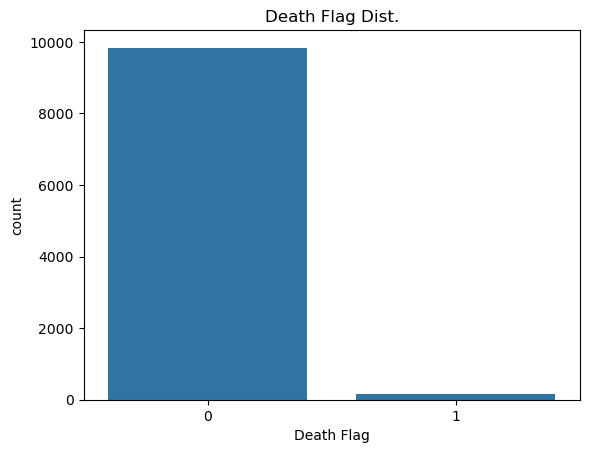

np.int64(162)

In [6]:
sns.countplot(x= 'Death Flag', data = clean_train)
plt.title('Death Flag Dist.')
plt.show()

(train['Death Flag'] == 1).sum()

Oh chungus, we only got 162 pos. cases. We are screwed.

# Death Flag VS Age, Death Flag VS BMI, Death Flag VS GLP Duration in Years

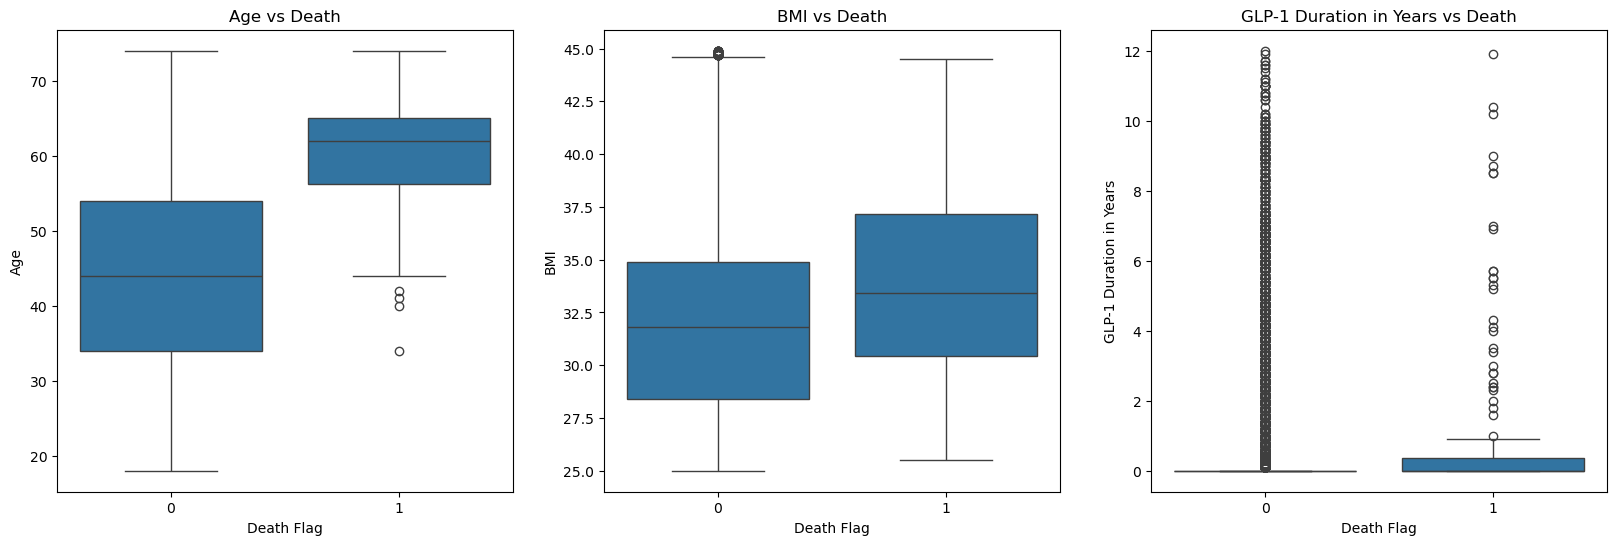

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.boxplot(x='Death Flag', y='Age', data= clean_train, ax = axes[0])
axes[0].set_title('Age vs Death')

sns.boxplot(x='Death Flag', y='BMI', data= clean_train, ax = axes[1])
axes[1].set_title('BMI vs Death')


sns.boxplot(x='Death Flag', y='GLP-1 Duration in Years', data= clean_train, ax = axes[2])
axes[2].set_title('GLP-1 Duration in Years vs Death')

plt.show()

As we have done some comparison of numerical data and death flag. Now lets do some categorical data.

/tmp/ipykernel_2499/450958650.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Excellent', 'Good', 'Fair', 'Poor'])


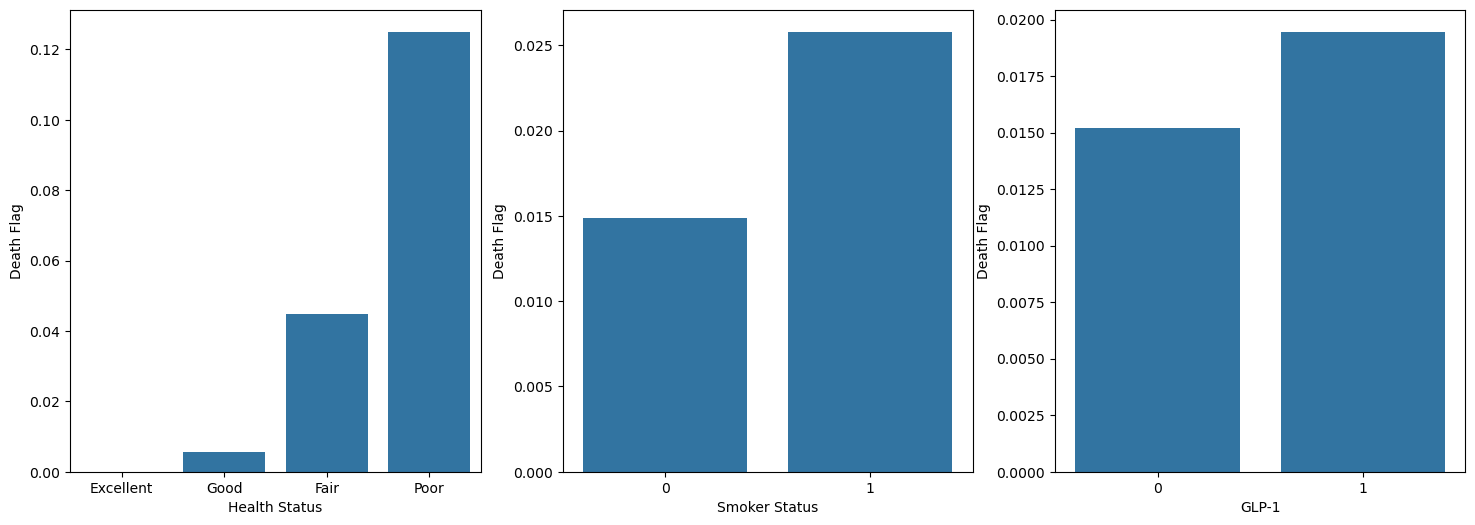

In [8]:
fig, axes = plt.subplots(1, 3, figsize = (18,6))

sns.barplot(x = 'Health Status', y = 'Death Flag', data = clean_train, ax = axes[0], errorbar = None
           , order = [1, 2, 3, 4])
axes[0].set_xticklabels(['Excellent', 'Good', 'Fair', 'Poor'])
# Please disregard thee Upcoming Index Warning
sns.barplot(x = 'Smoker Status', y = 'Death Flag', data = clean_train, ax = axes[1], errorbar = None)
sns.barplot(x = 'GLP-1', y = 'Death Flag', data = clean_train, ax = axes[2], errorbar = None) 

plt.show()

Text(0.5, 1.0, 'Correlation Matrix')

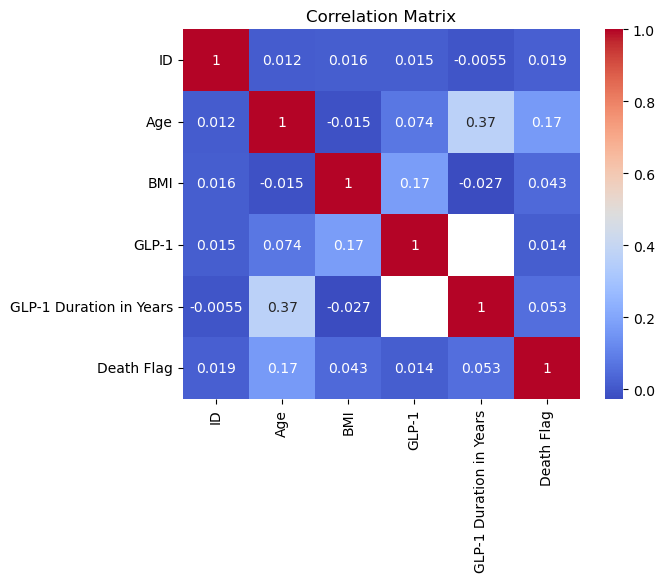

In [9]:
corr_mtrx = train.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_mtrx, annot = True, cmap = 'coolwarm')
plt.title('Correlation Matrix')

The above correlation matrix is cool. (I don't usually laugh at my puns:))

Now let's make some risk factors that will aid our tree search

In [10]:
train_fe = clean_train.copy()
test_fe = clean_test.copy()

for df in [train_fe, test_fe]:
    df['Age_BMI'] = df['Age'] * df['BMI']
    df['Age_Health'] = df['Age'] * df['Health Status']
    df['Smoker_Age'] = df['Age'] * df['Smoker Status']

    # GLP-1 interations
    # Duration per year of age
    df['GLP-1_Duration Age'] = df['GLP-1 Duration in Years'] / (df['Age'])
    df['GLP1_Active'] = ((df['GLP-1'] == 1) & (df['GLP-1 Duration in Years'] > 0))

train_fe.head(n=10)
# train_fe.head(n=10)

,ID,Age,Sex,Smoker Status,BMI,Health Status,GLP-1,GLP-1 Duration in Years,Province,Face Amount,Death Flag,Age_BMI,Age_Health,Smoker_Age,GLP-1_Duration Age,GLP1_Active
0,1,56,0,0,28.5,2,0,0.0,0,750000.0,0,1596.0,112,0,0.000000,False
1,2,50,0,0,26.7,2,1,3.2,1,250000.0,0,1335.0,100,0,0.064000,True
2,3,27,0,1,33.1,2,1,0.0,2,250000.0,0,893.7,54,27,0.000000,False
3,4,47,0,0,36.9,3,0,0.0,0,500000.0,0,1734.3,141,0,0.000000,False
4,5,56,0,0,25.7,2,0,0.0,2,100000.0,0,1439.2,112,0,0.000000,False
5,6,30,1,0,25.6,1,0,0.0,3,500000.0,0,768.0,30,0,0.000000,False
6,7,18,0,0,26.0,1,0,0.0,0,250000.0,0,468.0,18,0,0.000000,False
7,8,45,1,0,26.2,2,0,0.0,3,500000.0,0,1179.0,90,0,0.000000,False
8,9,35,0,0,29.5,2,0,0.0,2,750000.0,0,1032.5,70,0,0.000000,False
9,10,53,0,0,33.8,2,1,6.7,4,250000.0,0,1791.4,106,0,0.126415,True


## Remarks:
- Higher Age_BMI factor typically leads to a higher death count
- Higher Age_Health factor typically leads to higher death count

Cool lets rock and roll

In [11]:
!pip install lightgbm

In [ ]:
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

#1. Separate features and target
# We drop Id and Death Flag from the feactures
features = [c for c in train_fe.columns if c != 'Death Flag']
X = train_fe[features]
y = train_fe['Death Flag']
X_test = test_fe[features]

# Necessary Parameters for the Light Gradient Boosting Model
params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'learning_rate': .02,
    'num_leaves': 31,
    'max_depth': -1,
    'min_child_samples': 30,
    'feature_fraction': .8,
    'bagging_fraction': .8,
    'bagging_freq': 1,
    'lambda_l1': .1,
    'lambda_l2': .1,
    'is_unbalance': True,
    'random_state': 42,
    'n_jobs': -1,
    'verbosity': -1
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state = 42)

#Arrays to store predictions
oof_preds = np.zeros(len(X)) # Start with zeros for Out-Of-Fold predictions
test_preds = np.zeros(len(X_test)) # Predictions for the test

for fold, (train_idx, val_idx) in enumerate(skf.split(X ,y)):
    print(f"--- Fold {fold + 1} ---")

    #Split Data
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # Create LightGBM datasets
    dtrain = lgb.Dataset(X_train, label=y_train)
    dval = lgb.Dataset(X_val, label = y_val)

    #Train the model
    model = lgb.train(
        params,
        dtrain,
        num_boost_round = 2000,
        valid_sets = [dval],
        callbacks = [lgb.early_stopping(stopping_rounds = 100, verbose = False)]
    )
    #Predict on validation set
    oof_preds[val_idx] = model.predict(X_val, num_iteration=model.best_iteration)

    #Predict on test set (average across folds)
    test_preds += model.predict(X_test, num_iteration=model.best_iteration) / skf.n_splits

    #Print Fold AUC
    fold_auc = roc_auc_score(y_val, oof_preds[val_idx])
    print(f"Fold {fold+1} AUC: {fold_auc:.4f}")

overall_auc = roc_auc_score(y, oof_preds)
print(f"\nOverall OOF AUC: {overall_auc :.4f}")

--- Fold 1 ---
